In [1]:
## if you run in google colab, you need to uncomment the following and download the data and XRO source code to run this notebook

# run_google_colab = True
run_google_colab = False

import importlib.util
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore")

# Function to check and install a package if not found
def install_if_missing(package):
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    else:
        print(f"{package} is already installed.")

# List of required packages
required_packages = [
    "matplotlib", "numpy", "xarray", "nc-time-axis", "cftime", "climpred", "dateutil", "seaborn",
]

if run_google_colab:
    # Install missing packages if needed
    for pkg in required_packages:
        install_if_missing(pkg)

# Importing libraries after ensuring they are installed
%config IPCompleter.greedy = True
%matplotlib inline
%config InlineBackend.figure_format='retina'
%load_ext autoreload
%autoreload 2

import datetime

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from climpred import HindcastEnsemble
from dateutil.relativedelta import *
from matplotlib.ticker import AutoMinorLocator


In [2]:
if run_google_colab:
    # Download necessary files if running in Google Colab
    !wget -cq https://github.com/senclimate/XRO/raw/main/data/XRO_indices_oras5.nc
    !wget -cq https://github.com/senclimate/XRO/raw/main/code/XRO.py
    !wget -cq https://github.com/senclimate/XRO/raw/main/code/XRO_utils.py

# def setup_module_path():
module_path = '/nird/home/yongyub/kimyy/Dropbox/source/python/all/Modules/XRO-main'
sys.path.append(module_path)

# Import necessary modules after ensuring files are available
from XRO import XRO, xcorr, SkewAccessor, plot_above_below_shading, plot_fill_between, pmtm
# from XRO_utils import SkewAccessor, plot_above_below_shading, plot_fill_between, pmtm

print("All required libraries are installed and imported successfully!")

All required libraries are installed and imported successfully!


In [3]:
import xarray as xr
import numpy as np

LIM_FILE = (
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
    "PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)

with xr.open_dataset(LIM_FILE) as ds:
    print(ds)
    print("\nstate_vector:")
    print(ds["state_vector"])

    states = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in ds["state_vector"]["state"].values
    ]
    print("\nstates:")
    print(states)

    print("\nperiod:")
    print(ds["state_vector"]["time"].values[0])
    print(ds["state_vector"]["time"].values[-1])

    print("\nregions:")
    print(ds["state_vector"]["region"].values)

<xarray.Dataset> Size: 942kB
Dimensions:                                (region: 21, month: 12,
                                            state_to: 11, state_from: 11,
                                            state: 11, time: 336, poly_coeff: 2)
Coordinates:
  * region                                 (region) int16 42B 1 2 3 ... 27 28 29
  * time                                   (time) datetime64[ns] 3kB 1998-01-...
  * state                                  (state) <U5 220B 'PP' ... 'SASD'
  * month                                  (month) int16 24B 1 2 3 ... 10 11 12
  * poly_coeff                             (poly_coeff) int64 16B 0 1
  * state_to                               (state_to) <U5 220B 'PP' ... 'SASD'
  * state_from                             (state_from) <U5 220B 'PP' ... 'SASD'
Data variables: (12/24)
    G                                      (region, month, state_to, state_from) float32 122kB ...
    C0                                     (region, month, state_

In [4]:
import importlib
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr


# ============================================================
# Files / settings
# ============================================================

LIM_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
    "PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)

OUT_DIR = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/XRO/skill"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FILE = OUT_DIR / (
    "XRO_PP_forecast_skill_24month_"
    "3month_running_mean_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

MAX_LEAD = 24
INTERNAL_MAX_LEAD = MAX_LEAD + 1  # lead 24 needs leads 23, 24, 25
THRESHOLD = 0.5

# XRO fit/integration settings: retained from the previous XRO setup.
XRO_NCYCLE = 12
XRO_AC_ORDER = 2
XRO_IS_FORWARD = True
XRO_NSTEP = 10
XRO_NCOPY = 1
XRO_NOISE_TYPE = "zero"

MASK_NT = ["T2", "TH"]
MASK_NH = ["T2"]
MASK_B = ["IOD"]

# IMPORTANT:
# XRO.fit_matrix assumes that the first two variables are ENSO T and H.
# Therefore PP must not be first even though it is first in the LIM file.
XRO_STATE_ORDER = [
    "TENSO",
    "WWV",
    "NPMM",
    "SPMM",
    "IOB",
    "IOD",
    "SIOD",
    "TNA",
    "ATL3",
    "SASD",
    "PP",
]

TARGET_STATE = "PP"


# ============================================================
# Import XRO
# ============================================================

def load_xro_class():
    """
    Try common import paths used by the XRO package.

    If none works, replace this function with the exact import statement
    already used in the working XRO notebook, for example:
        from xro import XRO
    """
    candidates = [
        ("xro", "XRO"),
        ("XRO", "XRO"),
        ("xro.core", "XRO"),
        ("XRO.core", "XRO"),
    ]

    errors = []
    for module_name, class_name in candidates:
        try:
            module = importlib.import_module(module_name)
            return getattr(module, class_name)
        except Exception as exc:
            errors.append(f"{module_name}: {type(exc).__name__}: {exc}")

    msg = "\n".join(errors)
    raise ImportError(
        "Could not import the XRO class. Use the same import statement as in "
        "the existing working XRO notebook.\nTried:\n" + msg
    )


XRO = load_xro_class()


# ============================================================
# Helpers
# ============================================================

def decode_strings(values):
    return np.asarray([
        v.decode("utf-8") if isinstance(v, bytes) else str(v)
        for v in values
    ])


def corr_1d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)

    if ok.sum() < 3:
        return np.nan

    a = a[ok]
    b = b[ok]

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


def centered_mean_3_timeseries(x):
    """
    Strict centered 3-month mean of an observed time series.

    At target time t:
        mean(x[t-1], x[t], x[t+1])
    """
    x = np.asarray(x, dtype=np.float64)
    out = np.full(x.shape, np.nan, dtype=np.float64)

    if x.size < 3:
        return out

    window = np.stack([x[:-2], x[1:-1], x[2:]], axis=1)
    good = np.isfinite(window).all(axis=1)
    out[np.where(good)[0] + 1] = window[good].mean(axis=1)
    return out


def centered_mean_3_forecast(raw_forecast, max_lead):
    """
    Strict centered 3-month mean along forecast lead.

    For nominal lead L:
        mean(forecast[L-1], forecast[L], forecast[L+1])

    raw_forecast must have dimensions [init_time, lead] and include
    lead 0 through max_lead + 1.
    """
    raw_forecast = np.asarray(raw_forecast, dtype=np.float64)

    if raw_forecast.ndim != 2:
        raise ValueError(
            f"Forecast must have two dimensions [init, lead], "
            f"received shape {raw_forecast.shape}."
        )

    required_nlead = max_lead + 2  # lead 0 ... max_lead+1
    if raw_forecast.shape[1] < required_nlead:
        raise ValueError(
            f"Forecast must include lead 0 through {max_lead + 1}; "
            f"received shape {raw_forecast.shape}."
        )

    out = np.full(
        (raw_forecast.shape[0], max_lead),
        np.nan,
        dtype=np.float64,
    )

    for lead in range(1, max_lead + 1):
        window = raw_forecast[:, lead - 1:lead + 2]
        good = np.isfinite(window).all(axis=1)
        out[good, lead - 1] = window[good].mean(axis=1)

    return out


def latest_skill_month(skill, threshold):
    """
    Latest lead satisfying the threshold, not necessarily contiguous
    from lead 1.
    """
    good = np.where(np.isfinite(skill) & (skill >= threshold))[0]
    return 0 if good.size == 0 else int(good.max() + 1)


def state_vector_to_xro_dataset(state_vector, region, state_order):
    """
    Convert one regional LIM state vector to an xr.Dataset in the exact
    variable order required by XRO.

    XRO.fit_matrix identifies variables from Dataset insertion order.
    The first two variables must therefore be TENSO and WWV.
    """
    da = (
        state_vector.sel(region=region)
        .transpose("time", "state")
        .astype(np.float64)
    )

    available = set(decode_strings(da["state"].values))
    missing = [name for name in state_order if name not in available]
    if missing:
        raise KeyError(
            f"Region {int(region)} is missing required XRO states: {missing}"
        )

    ds = xr.Dataset(
        data_vars={
            name: (
                "time",
                da.sel(state=name).values.astype(np.float64),
            )
            for name in state_order
        },
        coords={"time": da["time"].values},
    )

    # The supplied XRO implementation removes NaNs using only one state.
    # A complete finite state vector is therefore required here.
    arr = ds.to_array("variable").transpose("variable", "time").values
    if not np.isfinite(arr).all():
        bad = np.argwhere(~np.isfinite(arr))
        first = bad[0]
        bad_var = state_order[int(first[0])]
        bad_time = pd.Timestamp(ds.time.values[int(first[1])])
        raise ValueError(
            f"Non-finite XRO input in region {int(region)}: "
            f"state={bad_var}, time={bad_time:%Y-%m}."
        )

    return ds


# ============================================================
# Load the LIM training state
# ============================================================

if not LIM_FILE.exists():
    raise FileNotFoundError(f"LIM file not found: {LIM_FILE}")

with xr.open_dataset(LIM_FILE) as ds:
    ds_lim = ds.load()

if "state_vector" not in ds_lim:
    raise KeyError(f"state_vector not found in {LIM_FILE}")

state_vector = ds_lim["state_vector"].transpose("region", "time", "state")
regions = state_vector["region"].values
states_in_file = decode_strings(state_vector["state"].values)
times = state_vector["time"].values
months = pd.to_datetime(times).month.values.astype(np.int16)

missing_states = [
    name for name in XRO_STATE_ORDER if name not in set(states_in_file)
]
if missing_states:
    raise KeyError(
        f"Required XRO states are absent from the LIM file: {missing_states}. "
        f"Available states: {list(states_in_file)}"
    )

n_region = len(regions)
n_time = len(times)

lead_coord = np.arange(1, MAX_LEAD + 1, dtype=np.int16)
init_month_coord = np.arange(1, 13, dtype=np.int16)

print("Training state file:", LIM_FILE)
print("Training period:", times[0], "to", times[-1])
print("Number of months:", n_time)
print("Number of regions:", n_region)
print("States stored in LIM file:", list(states_in_file))
print("States passed to XRO:", XRO_STATE_ORDER)
print("XRO options:")
print("  ncycle:", XRO_NCYCLE)
print("  ac_order:", XRO_AC_ORDER)
print("  is_forward:", XRO_IS_FORWARD)
print("  maskNT:", MASK_NT)
print("  maskNH:", MASK_NH)
print("  maskb:", MASK_B)
print("Forecast noise:", XRO_NOISE_TYPE)
print("Skill smoothing: strict centered 3-month mean")


# ============================================================
# Allocate output arrays
# ============================================================

pp_corr = np.full(
    (n_region, MAX_LEAD),
    np.nan,
    dtype=np.float64,
)
n_pairs = np.zeros(
    (n_region, MAX_LEAD),
    dtype=np.int16,
)

pp_corr_by_init_month = np.full(
    (n_region, 12, MAX_LEAD),
    np.nan,
    dtype=np.float64,
)
n_pairs_by_init_month = np.zeros(
    (n_region, 12, MAX_LEAD),
    dtype=np.int16,
)

# Already-smoothed forecasts at nominal leads 1...24.
pp_pred = np.full(
    (n_region, n_time, MAX_LEAD),
    np.nan,
    dtype=np.float32,
)


# ============================================================
# Fit XRO, reforecast, and calculate skill
# ============================================================

for ir, reg in enumerate(regions):
    print(f"\n[{ir + 1:02d}/{n_region:02d}] region {int(reg)}")

    obs_region = state_vector_to_xro_dataset(
        state_vector=state_vector,
        region=reg,
        state_order=XRO_STATE_ORDER,
    )

    # A separate 11-state XRO is fitted for every PP region.
    # TENSO and WWV must be the first two variables.
    xro_model = XRO(
        ncycle=XRO_NCYCLE,
        ac_order=XRO_AC_ORDER,
        is_forward=XRO_IS_FORWARD,
    )

    fit_ds = xro_model.fit_matrix(
        obs_region,
        maskNT=MASK_NT,
        maskNH=MASK_NH,
        maskb=MASK_B,
    )

    # Forecast through lead 25 so nominal lead 24 can average
    # raw forecast leads 23, 24, and 25.
    fcst_ds = xro_model.reforecast(
        fit_ds=fit_ds,
        init_ds=obs_region,
        n_month=INTERNAL_MAX_LEAD,
        nstep=XRO_NSTEP,
        ncopy=XRO_NCOPY,
        noise_type=XRO_NOISE_TYPE,
    )

    if TARGET_STATE not in fcst_ds:
        raise KeyError(
            f"{TARGET_STATE} not found in XRO reforecast output for "
            f"region {int(reg)}. Variables: {list(fcst_ds.data_vars)}"
        )

    pp_raw = (
        fcst_ds[TARGET_STATE]
        .transpose("init", "lead")
        .values.astype(np.float64)
    )

    if pp_raw.shape[0] != n_time:
        raise ValueError(
            f"Unexpected number of initializations for region {int(reg)}: "
            f"{pp_raw.shape[0]} instead of {n_time}."
        )

    pp_forecast_3mon = centered_mean_3_forecast(
        pp_raw,
        max_lead=MAX_LEAD,
    )

    obs_pp_3mon = centered_mean_3_timeseries(
        obs_region[TARGET_STATE].values
    )

    pp_pred[ir] = pp_forecast_3mon.astype(np.float32)

    for lead in range(1, MAX_LEAD + 1):
        # Need target+1 for the centered observed mean.
        init_idx = np.arange(0, n_time - lead - 1, dtype=int)

        pred = pp_forecast_3mon[init_idx, lead - 1]
        obs = obs_pp_3mon[init_idx + lead]
        ok = np.isfinite(pred) & np.isfinite(obs)

        n_pairs[ir, lead - 1] = int(ok.sum())
        pp_corr[ir, lead - 1] = corr_1d(pred, obs)

        for init_month in range(1, 13):
            idx_m = init_idx[months[init_idx] == init_month]

            pred_m = pp_forecast_3mon[idx_m, lead - 1]
            obs_m = obs_pp_3mon[idx_m + lead]
            ok_m = np.isfinite(pred_m) & np.isfinite(obs_m)

            n_pairs_by_init_month[
                ir, init_month - 1, lead - 1
            ] = int(ok_m.sum())

            pp_corr_by_init_month[
                ir, init_month - 1, lead - 1
            ] = corr_1d(pred_m, obs_m)

    print(
        "  pooled latest lead r>=0.5:",
        latest_skill_month(pp_corr[ir], THRESHOLD),
    )


# ============================================================
# Latest lead satisfying r >= 0.5
# ============================================================

latest_lead = np.zeros(n_region, dtype=np.int16)
latest_lead_by_init_month = np.zeros(
    (n_region, 12),
    dtype=np.int16,
)

for ir in range(n_region):
    latest_lead[ir] = latest_skill_month(
        pp_corr[ir],
        THRESHOLD,
    )

    for im in range(12):
        latest_lead_by_init_month[ir, im] = latest_skill_month(
            pp_corr_by_init_month[ir, im],
            THRESHOLD,
        )


# ============================================================
# Region metadata
# ============================================================

region_name_values = (
    decode_strings(ds_lim["region_name"].sel(region=regions).values)
    if "region_name" in ds_lim
    else np.asarray([f"region {int(r)}" for r in regions])
)

basin_values = (
    decode_strings(ds_lim["basin"].sel(region=regions).values)
    if "basin" in ds_lim
    else np.asarray([""] * n_region)
)

original_region_id_values = (
    ds_lim["original_region_id"]
    .sel(region=regions)
    .values.astype(np.int16)
    if "original_region_id" in ds_lim
    else np.full(n_region, -999, dtype=np.int16)
)


# ============================================================
# Output dataset
# ============================================================

ds_skill = xr.Dataset(
    data_vars={
        "PP_prediction": (
            ("region", "init_time", "lead"),
            pp_pred,
            {
                "long_name": (
                    "Centered 3-month running-mean PP prediction from XRO"
                ),
                "description": (
                    "Nominal lead L averages raw XRO forecast leads "
                    "L-1, L, and L+1."
                ),
                "units": "standard deviation",
            },
        ),
        "PP_correlation_skill": (
            ("region", "lead"),
            pp_corr.astype(np.float32),
            {
                "long_name": (
                    "PP forecast correlation skill using centered "
                    "3-month means"
                ),
                "threshold_reference": THRESHOLD,
            },
        ),
        "PP_correlation_skill_by_init_month": (
            ("region", "init_month", "lead"),
            pp_corr_by_init_month.astype(np.float32),
            {
                "long_name": (
                    "PP correlation skill by initialization month using "
                    "centered 3-month means"
                ),
                "threshold_reference": THRESHOLD,
            },
        ),
        "n_pairs": (
            ("region", "lead"),
            n_pairs,
            {
                "long_name": (
                    "Number of valid XRO forecast-observation pairs"
                )
            },
        ),
        "n_pairs_by_init_month": (
            ("region", "init_month", "lead"),
            n_pairs_by_init_month,
            {
                "long_name": (
                    "Number of valid XRO pairs by initialization month"
                )
            },
        ),
        "latest_lead_corr_ge_05": (
            ("region",),
            latest_lead,
            {
                "long_name": (
                    "Latest lead with centered 3-month PP correlation >= 0.5"
                ),
                "units": "month",
            },
        ),
        "latest_lead_corr_ge_05_by_init_month": (
            ("region", "init_month"),
            latest_lead_by_init_month,
            {
                "long_name": (
                    "Latest lead with centered 3-month PP correlation >= 0.5 "
                    "by initialization month"
                ),
                "units": "month",
            },
        ),
        "region_name": (
            ("region",),
            region_name_values.astype(object),
        ),
        "basin": (
            ("region",),
            basin_values.astype(object),
        ),
        "original_region_id": (
            ("region",),
            original_region_id_values,
        ),
    },
    coords={
        "region": regions.astype(np.int16),
        "init_time": times,
        "lead": lead_coord,
        "init_month": init_month_coord,
    },
    attrs={
        "title": (
            "Centered 3-month PP forecast skill from regional nonlinear XRO"
        ),
        "training_state_file": str(LIM_FILE),
        "training_period": (
            f"{pd.Timestamp(times[0]):%Y-%m-%d} to "
            f"{pd.Timestamp(times[-1]):%Y-%m-%d}"
        ),
        "important_note": (
            "The XRO is fitted and verified in-sample using the same "
            "standardized monthly state vector used to train the LIM."
        ),
        "xro_state_order": ", ".join(XRO_STATE_ORDER),
        "target_state": TARGET_STATE,
        "xro_ncycle": XRO_NCYCLE,
        "xro_ac_order": XRO_AC_ORDER,
        "xro_is_forward": str(XRO_IS_FORWARD),
        "xro_maskNT": ", ".join(MASK_NT),
        "xro_maskNH": ", ".join(MASK_NH),
        "xro_maskb": ", ".join(MASK_B),
        "xro_nstep": XRO_NSTEP,
        "forecast_noise_type": XRO_NOISE_TYPE,
        "max_nominal_lead_months": MAX_LEAD,
        "internal_forecast_max_lead_months": INTERNAL_MAX_LEAD,
        "running_mean_months": 3,
        "running_mean_alignment": "centered along forecast lead/target time",
        "correlation_threshold": THRESHOLD,
        "method": (
            "For each region, a separate 11-state nonlinear XRO is fitted "
            "to the unsmoothed standardized monthly state vector. The state "
            "order is rearranged so TENSO and WWV are first, as required by "
            "XRO.fit_matrix, and regional PP is last. Deterministic zero-noise "
            "reforecasts are initialized from every monthly state. Immediately "
            "before verification, predicted and observed PP are converted to "
            "strict centered 3-month means. For nominal lead L, the forecast "
            "uses raw leads L-1, L, and L+1, while the observation uses the "
            "three target months centered on init+L."
        ),
        "date_created": date.today().isoformat(),
    },
)

ds_skill["lead"].attrs.update({
    "long_name": "Nominal lead of centered 3-month XRO forecast",
    "units": "month",
})
ds_skill["init_month"].attrs.update({
    "long_name": "Initialization month",
})


# ============================================================
# Save
# ============================================================

encoding = {
    "PP_prediction": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_correlation_skill": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_correlation_skill_by_init_month": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "n_pairs": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "n_pairs_by_init_month": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "latest_lead_corr_ge_05": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "latest_lead_corr_ge_05_by_init_month": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "original_region_id": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "region": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "lead": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "init_month": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "init_time": {
        "dtype": "float64",
        "units": "days since 1900-01-01",
        "calendar": "gregorian",
    },
}

if OUT_FILE.exists():
    OUT_FILE.unlink()

ds_skill.to_netcdf(
    OUT_FILE,
    encoding=encoding,
    engine="netcdf4",
)

print("\nSaved:", OUT_FILE)
print(ds_skill)


Training state file: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc
Training period: 1998-01-15T00:00:00.000000000 to 2025-12-15T00:00:00.000000000
Number of months: 336
Number of regions: 21
States stored in LIM file: [np.str_('PP'), np.str_('TENSO'), np.str_('WWV'), np.str_('NPMM'), np.str_('SPMM'), np.str_('IOB'), np.str_('IOD'), np.str_('SIOD'), np.str_('TNA'), np.str_('ATL3'), np.str_('SASD')]
States passed to XRO: ['TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD', 'PP']
XRO options:
  ncycle: 12
  ac_order: 2
  is_forward: True
  maskNT: ['T2', 'TH']
  maskNH: ['T2']
  maskb: ['IOD']
Forecast noise: zero
Skill smoothing: strict centered 3-month mean

[01/21] region 1
  pooled latest lead r>=0.5: 1

[02/21] region 2
  pooled latest lead r>=0.5: 1

[03/21] region 3
  pooled latest lead r>=0.5: 8

[04/21] region 4
  pooled latest lead r>=0.5: 2

[05/21] region 

Skill file:
/nird/datalake/NS11071K/users/yongyub/DD_BGC/XRO/skill/XRO_PP_forecast_skill_24month_3month_running_mean_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc

Skill description:
Latest lead with centered 3-month PP correlation >= 0.5

Original mask regions:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]

Plot mask regions:
[ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 27 28]

Original skill regions:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]

Plotted skill regions:
[ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 27 28]

Latest skillful lead:
Region  1:  1 months
Region  2:  1 months
Region  3:  8 months
Region  4:  2 months
Region  5:  4 months
Region  7:  1 months
Region  8:  2 months
Region  9: 15 months
Region 10: 11 months
Region 11:  8 months
Region 12:  4 months
Region 13:  3 months
Region 14:  3 months
Region 15: 13 months
Region 16:  4 months
Region 27:  4 months
Region 28:  2 months


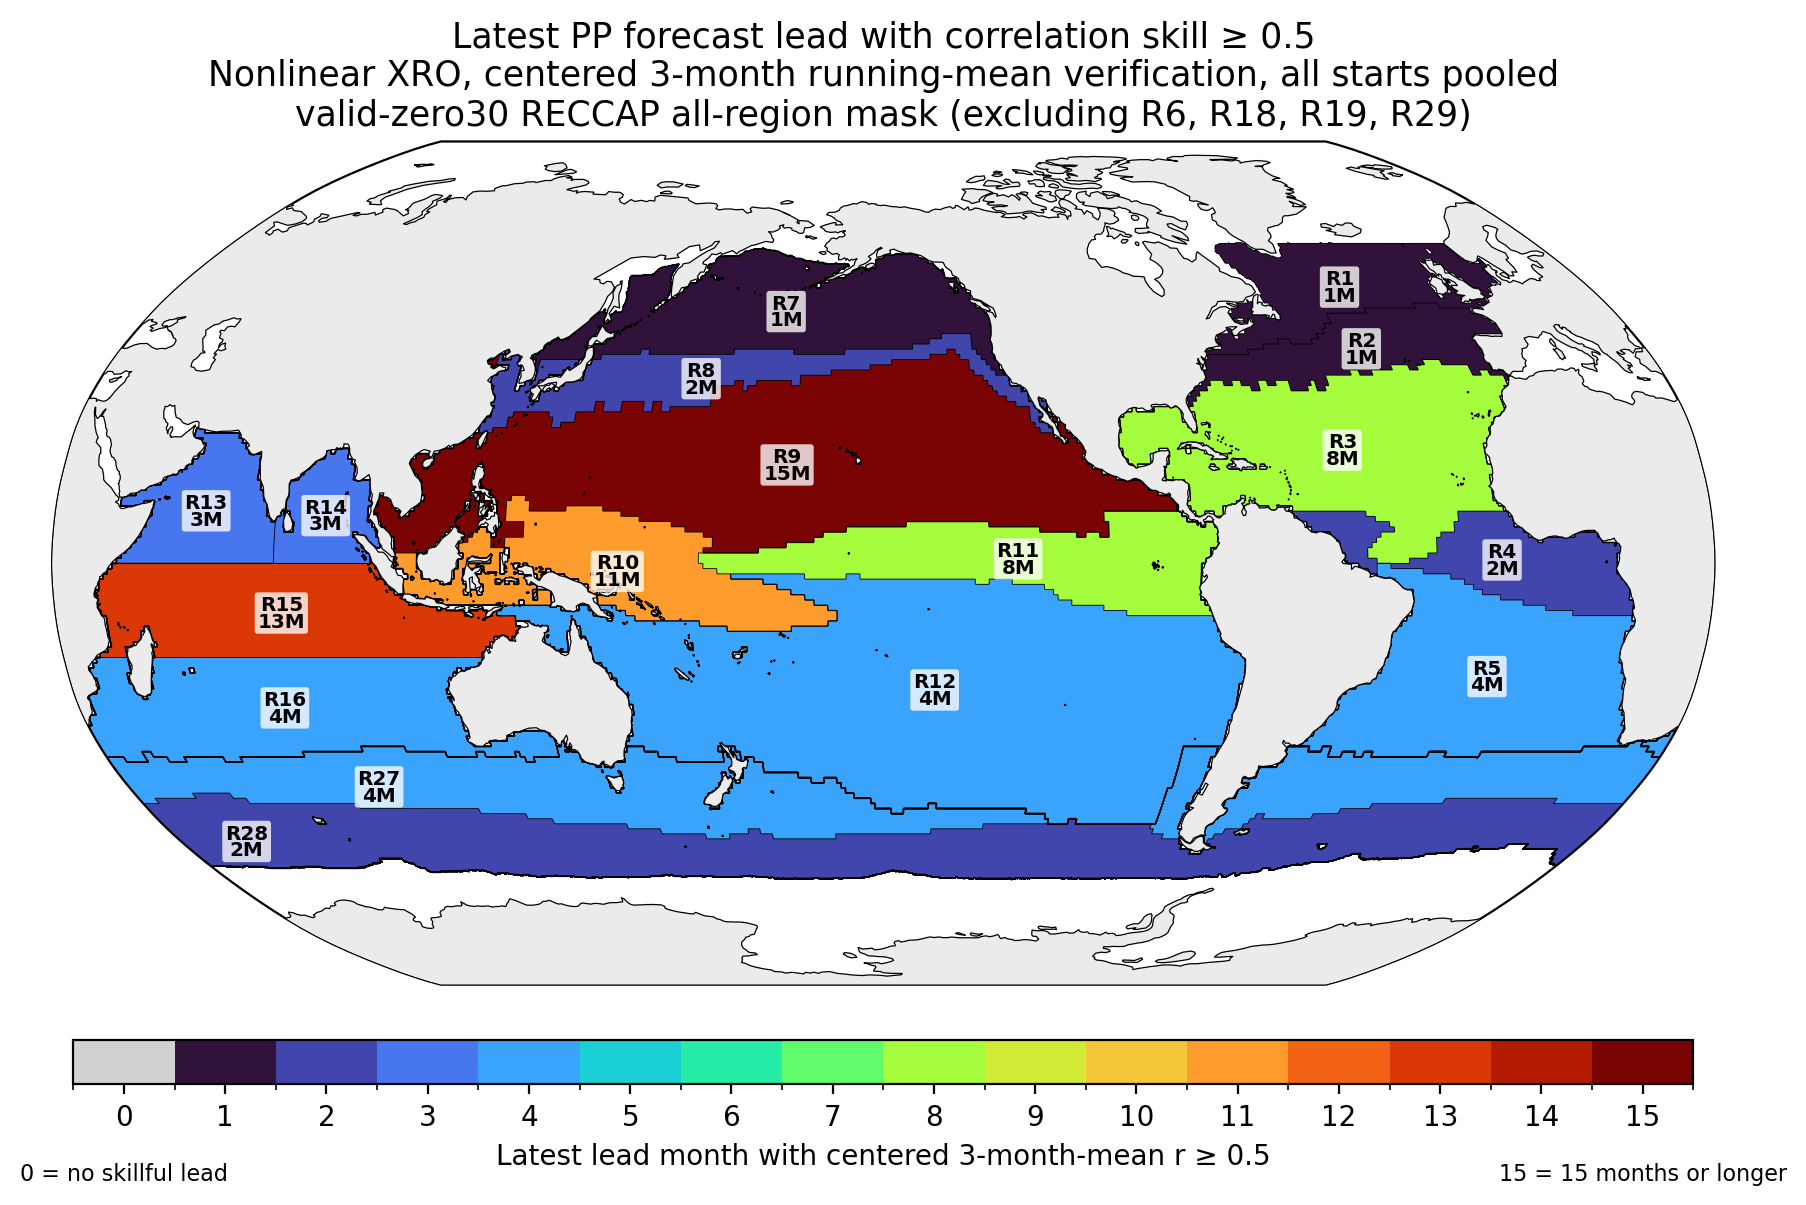

In [5]:
# ============================================================
# Map latest XRO skillful lead by valid-zero30 RECCAP region
# using centered 3-month running-mean PP skill
# excluding selected regions only for plotting
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path


# ============================================================
# Files
# ============================================================

VALID_MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "GlobColour_PP_grid_validity_RECCAP2_all_regions/"
    "valid_mask_zero30/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)

# XRO skill calculated after applying centered 3-month running means
# to both predicted and observed PP
SKILL_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/XRO/skill/"
    "XRO_PP_forecast_skill_24month_"
    "3month_running_mean_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

MAX_LEAD = 24
THRESHOLD = 0.5

CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4

# Regions to exclude only in this figure
EXCLUDE_PLOT_REGIONS = [6, 18, 19, 29]

# Values above this lead are displayed with the same final color
DISPLAY_MAX_LEAD = 15

OUT_FIG = SKILL_FILE.parent / (
    "Map_latest_XRO_PP_skillful_lead_3month_running_mean_corr_ge_05_"
    "RECCAP2_all_regions_valid_zero30_excluding_R6_R18_R19_R29.png"
)


# ============================================================
# Helper functions
# ============================================================

def lon_to_180(lon):
    """
    Convert longitude from 0–360 to -180–180.
    """
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, mask):
    """
    Calculate an area-weighted centroid using cosine-latitude weights.

    Longitude is calculated using a circular mean so that regions
    crossing the dateline are handled correctly.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    wsum = np.nansum(weights)

    if wsum <= 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)

    x = np.nansum(weights * np.cos(lon_rad)) / wsum
    y = np.nansum(weights * np.sin(lon_rad)) / wsum

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / wsum

    return lon_c, lat_c


def add_cyclic_manual(data, lon):
    """
    Add a cyclic longitude column without requiring perfectly
    equally spaced longitudes.
    """
    lon = np.asarray(lon, dtype=np.float64)

    sort_idx = np.argsort(lon)
    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]

    dlon = float(np.nanmedian(np.diff(lon_sorted)))

    lon_cyc = np.concatenate(
        [lon_sorted, [lon_sorted[-1] + dlon]]
    )

    data_cyc = np.concatenate(
        [data_sorted, data_sorted[:, :1]],
        axis=1,
    )

    return data_cyc, lon_cyc


# ============================================================
# Check files
# ============================================================

if not VALID_MASK_FILE.exists():
    raise FileNotFoundError(
        f"Valid mask file not found:\n{VALID_MASK_FILE}"
    )

if not SKILL_FILE.exists():
    raise FileNotFoundError(
        f"3-month running-mean skill file not found:\n{SKILL_FILE}"
    )


# ============================================================
# Load mask and skill
# ============================================================

ds_mask = xr.open_dataset(VALID_MASK_FILE)
ds_skill = xr.open_dataset(SKILL_FILE)

required_mask_var = "valid_region_mask"
required_skill_var = "latest_lead_corr_ge_05"

if required_mask_var not in ds_mask:
    raise KeyError(
        f"{required_mask_var} not found in:\n{VALID_MASK_FILE}"
    )

if required_skill_var not in ds_skill:
    raise KeyError(
        f"{required_skill_var} not found in:\n{SKILL_FILE}"
    )

mask = ds_mask[required_mask_var]
latest = ds_skill[required_skill_var]

lat = ds_mask["latitude"].values.astype(float)
lon = ds_mask["longitude"].values.astype(float)

mask_values = mask.values.astype(np.int16)


# ============================================================
# Exclude selected regions only for plotting
# ============================================================

mask_plot_full = mask_values.copy()

for reg_ex in EXCLUDE_PLOT_REGIONS:
    mask_plot_full[mask_plot_full == reg_ex] = 0


# Keep only regions that:
# 1. exist in the skill file
# 2. are not excluded from the figure
# 3. exist in the plotting mask
mask_region_set = set(
    np.unique(mask_plot_full[mask_plot_full > 0]).astype(int)
)

regions_to_plot = [
    int(reg)
    for reg in latest["region"].values
    if (
        int(reg) not in EXCLUDE_PLOT_REGIONS
        and int(reg) in mask_region_set
    )
]

latest_plot = latest.sel(region=regions_to_plot)

print("Skill file:")
print(SKILL_FILE)

print("\nSkill description:")
print(latest.attrs.get("long_name", ""))

print("\nOriginal mask regions:")
print(np.unique(mask_values[mask_values > 0]))

print("\nPlot mask regions:")
print(np.unique(mask_plot_full[mask_plot_full > 0]))

print("\nOriginal skill regions:")
print(latest["region"].values)

print("\nPlotted skill regions:")
print(latest_plot["region"].values)

print("\nLatest skillful lead:")
for reg in latest_plot["region"].values:
    reg = int(reg)
    value = int(latest_plot.sel(region=reg).values)
    print(f"Region {reg:2d}: {value:2d} months")


# ============================================================
# Build latest-lead map on PP grid
# ============================================================

lead_map = np.full(
    mask_values.shape,
    np.nan,
    dtype=np.float32,
)

for reg in latest_plot["region"].values:
    reg = int(reg)

    value = float(
        latest_plot.sel(region=reg).values
    )

    lead_map[mask_plot_full == reg] = value


# Outside retained regions -> NaN
lead_map = np.where(
    mask_plot_full > 0,
    lead_map,
    np.nan,
)


# ============================================================
# Coarsen for plotting only
# ============================================================

lat_plot = lat[::PLOT_STRIDE]
lon_plot = lon[::PLOT_STRIDE]

lead_plot = lead_map[
    ::PLOT_STRIDE,
    ::PLOT_STRIDE,
]

mask_plot = mask_plot_full[
    ::PLOT_STRIDE,
    ::PLOT_STRIDE,
].astype(float)

lead_cyc, lon_cyc = add_cyclic_manual(
    lead_plot,
    lon_plot,
)

mask_cyc, _ = add_cyclic_manual(
    mask_plot,
    lon_plot,
)


# Region boundary levels
remaining_regions = np.unique(
    mask_plot_full[mask_plot_full > 0]
)

if remaining_regions.size == 0:
    raise ValueError(
        "No regions remain after applying EXCLUDE_PLOT_REGIONS."
    )

boundary_levels = np.arange(
    0.5,
    int(np.nanmax(remaining_regions)) + 1.5,
    1.0,
)


# ============================================================
# Discrete color scale
# ============================================================

# Leads above DISPLAY_MAX_LEAD use the same final color.
# Lead 0 means no lead reached correlation >= 0.5.
lead_cyc_plot = np.where(
    np.isfinite(lead_cyc),
    np.minimum(lead_cyc, DISPLAY_MAX_LEAD),
    np.nan,
)

bounds = np.arange(
    -0.5,
    DISPLAY_MAX_LEAD + 1.5,
    1.0,
)

try:
    base = plt.get_cmap(
        "turbo",
        DISPLAY_MAX_LEAD,
    )
except ValueError:
    base = plt.get_cmap(
        "plasma",
        DISPLAY_MAX_LEAD,
    )

# First color is for lead 0
colors = (
    [(0.82, 0.82, 0.82, 1.0)]
    + [base(i) for i in range(DISPLAY_MAX_LEAD)]
)

cmap = ListedColormap(colors)
cmap.set_bad((1, 1, 1, 0))

norm = BoundaryNorm(
    bounds,
    cmap.N,
)


# ============================================================
# Plot
# ============================================================

fig = plt.figure(
    figsize=(13.5, 6.2)
)

ax = plt.axes(
    projection=ccrs.Robinson(
        central_longitude=CENTRAL_LONGITUDE
    )
)

im = ax.pcolormesh(
    lon_cyc,
    lat_plot,
    lead_cyc_plot,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree(),
)


# Valid RECCAP region boundaries after exclusion
ax.contour(
    lon_cyc,
    lat_plot,
    mask_cyc,
    levels=boundary_levels,
    colors="k",
    linewidths=0.30,
    transform=ccrs.PlateCarree(),
)


# Land and coastlines
ax.add_feature(
    cfeature.LAND,
    facecolor="0.92",
    edgecolor="none",
    zorder=3,
)

ax.coastlines(
    linewidth=0.45,
    zorder=4,
)

ax.set_global()


# ============================================================
# Title
# ============================================================

ax.set_title(
    "Latest PP forecast lead with correlation skill ≥ 0.5\n"
    "Nonlinear XRO, centered 3-month running-mean verification, "
    "all starts pooled\n"
    "valid-zero30 RECCAP all-region mask "
    "(excluding R6, R18, R19, R29)",
    fontsize=12.5,
)


# ============================================================
# Region labels: region code and latest lead
# ============================================================

for reg in latest_plot["region"].values:
    reg = int(reg)

    region_mask = mask_plot_full == reg

    if not np.any(region_mask):
        continue

    lon_c, lat_c = weighted_centroid(
        lon,
        lat,
        region_mask,
    )

    if not (
        np.isfinite(lon_c)
        and np.isfinite(lat_c)
    ):
        continue

    value = int(
        latest_plot.sel(region=reg).values
    )

    label_text = f"R{reg}\n{value}M"

    ax.text(
        lon_to_180(lon_c),
        lat_c,
        label_text,
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=7.2,
        fontweight="bold",
        linespacing=0.85,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.78,
            boxstyle="round,pad=0.14",
        ),
        zorder=5,
    )


# ============================================================
# Colorbar
# ============================================================

fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.84,
    bottom=0.16,
)

cax = fig.add_axes(
    [0.20, 0.08, 0.60, 0.035]
)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(
        0,
        DISPLAY_MAX_LEAD + 1,
        1,
    ),
    boundaries=bounds,
)

cbar.set_label(
    "Latest lead month with centered 3-month-mean r ≥ 0.5"
)

cbar.ax.text(
    0,
    -1.8,
    "0 = no skillful lead",
    ha="center",
    va="top",
    transform=cbar.ax.get_xaxis_transform(),
    fontsize=8,
)

# Indicate that the last displayed category also contains larger leads
cbar.ax.text(
    DISPLAY_MAX_LEAD,
    -1.8,
    f"{DISPLAY_MAX_LEAD} = {DISPLAY_MAX_LEAD} months or longer",
    ha="center",
    va="top",
    transform=cbar.ax.get_xaxis_transform(),
    fontsize=8,
)


# ============================================================
# Show / save
# ============================================================

plt.show()

# plt.savefig(
#     OUT_FIG,
#     dpi=200,
#     bbox_inches="tight",
# )
#
# print(f"Saved figure: {OUT_FIG}")


# ============================================================
# Close datasets
# ============================================================

ds_mask.close()
ds_skill.close()

Skill file:
/nird/datalake/NS11071K/users/yongyub/DD_BGC/XRO/skill/XRO_PP_forecast_skill_24month_3month_running_mean_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc

Dataset:
<xarray.Dataset> Size: 722kB
Dimensions:                               (region: 21, init_time: 336,
                                           lead: 24, init_month: 12)
Coordinates:
  * region                                (region) int16 42B 1 2 3 ... 27 28 29
  * init_time                             (init_time) datetime64[ns] 3kB 1998...
  * lead                                  (lead) int16 48B 1 2 3 4 ... 22 23 24
  * init_month                            (init_month) int16 24B 1 2 3 ... 11 12
Data variables:
    PP_prediction                         (region, init_time, lead) float32 677kB ...
    PP_correlation_skill                  (region, lead) float32 2kB ...
    PP_correlation_skill_by_init_month    (region, init_month, lead) float32 24kB ...
    n_pairs                               (region, lead

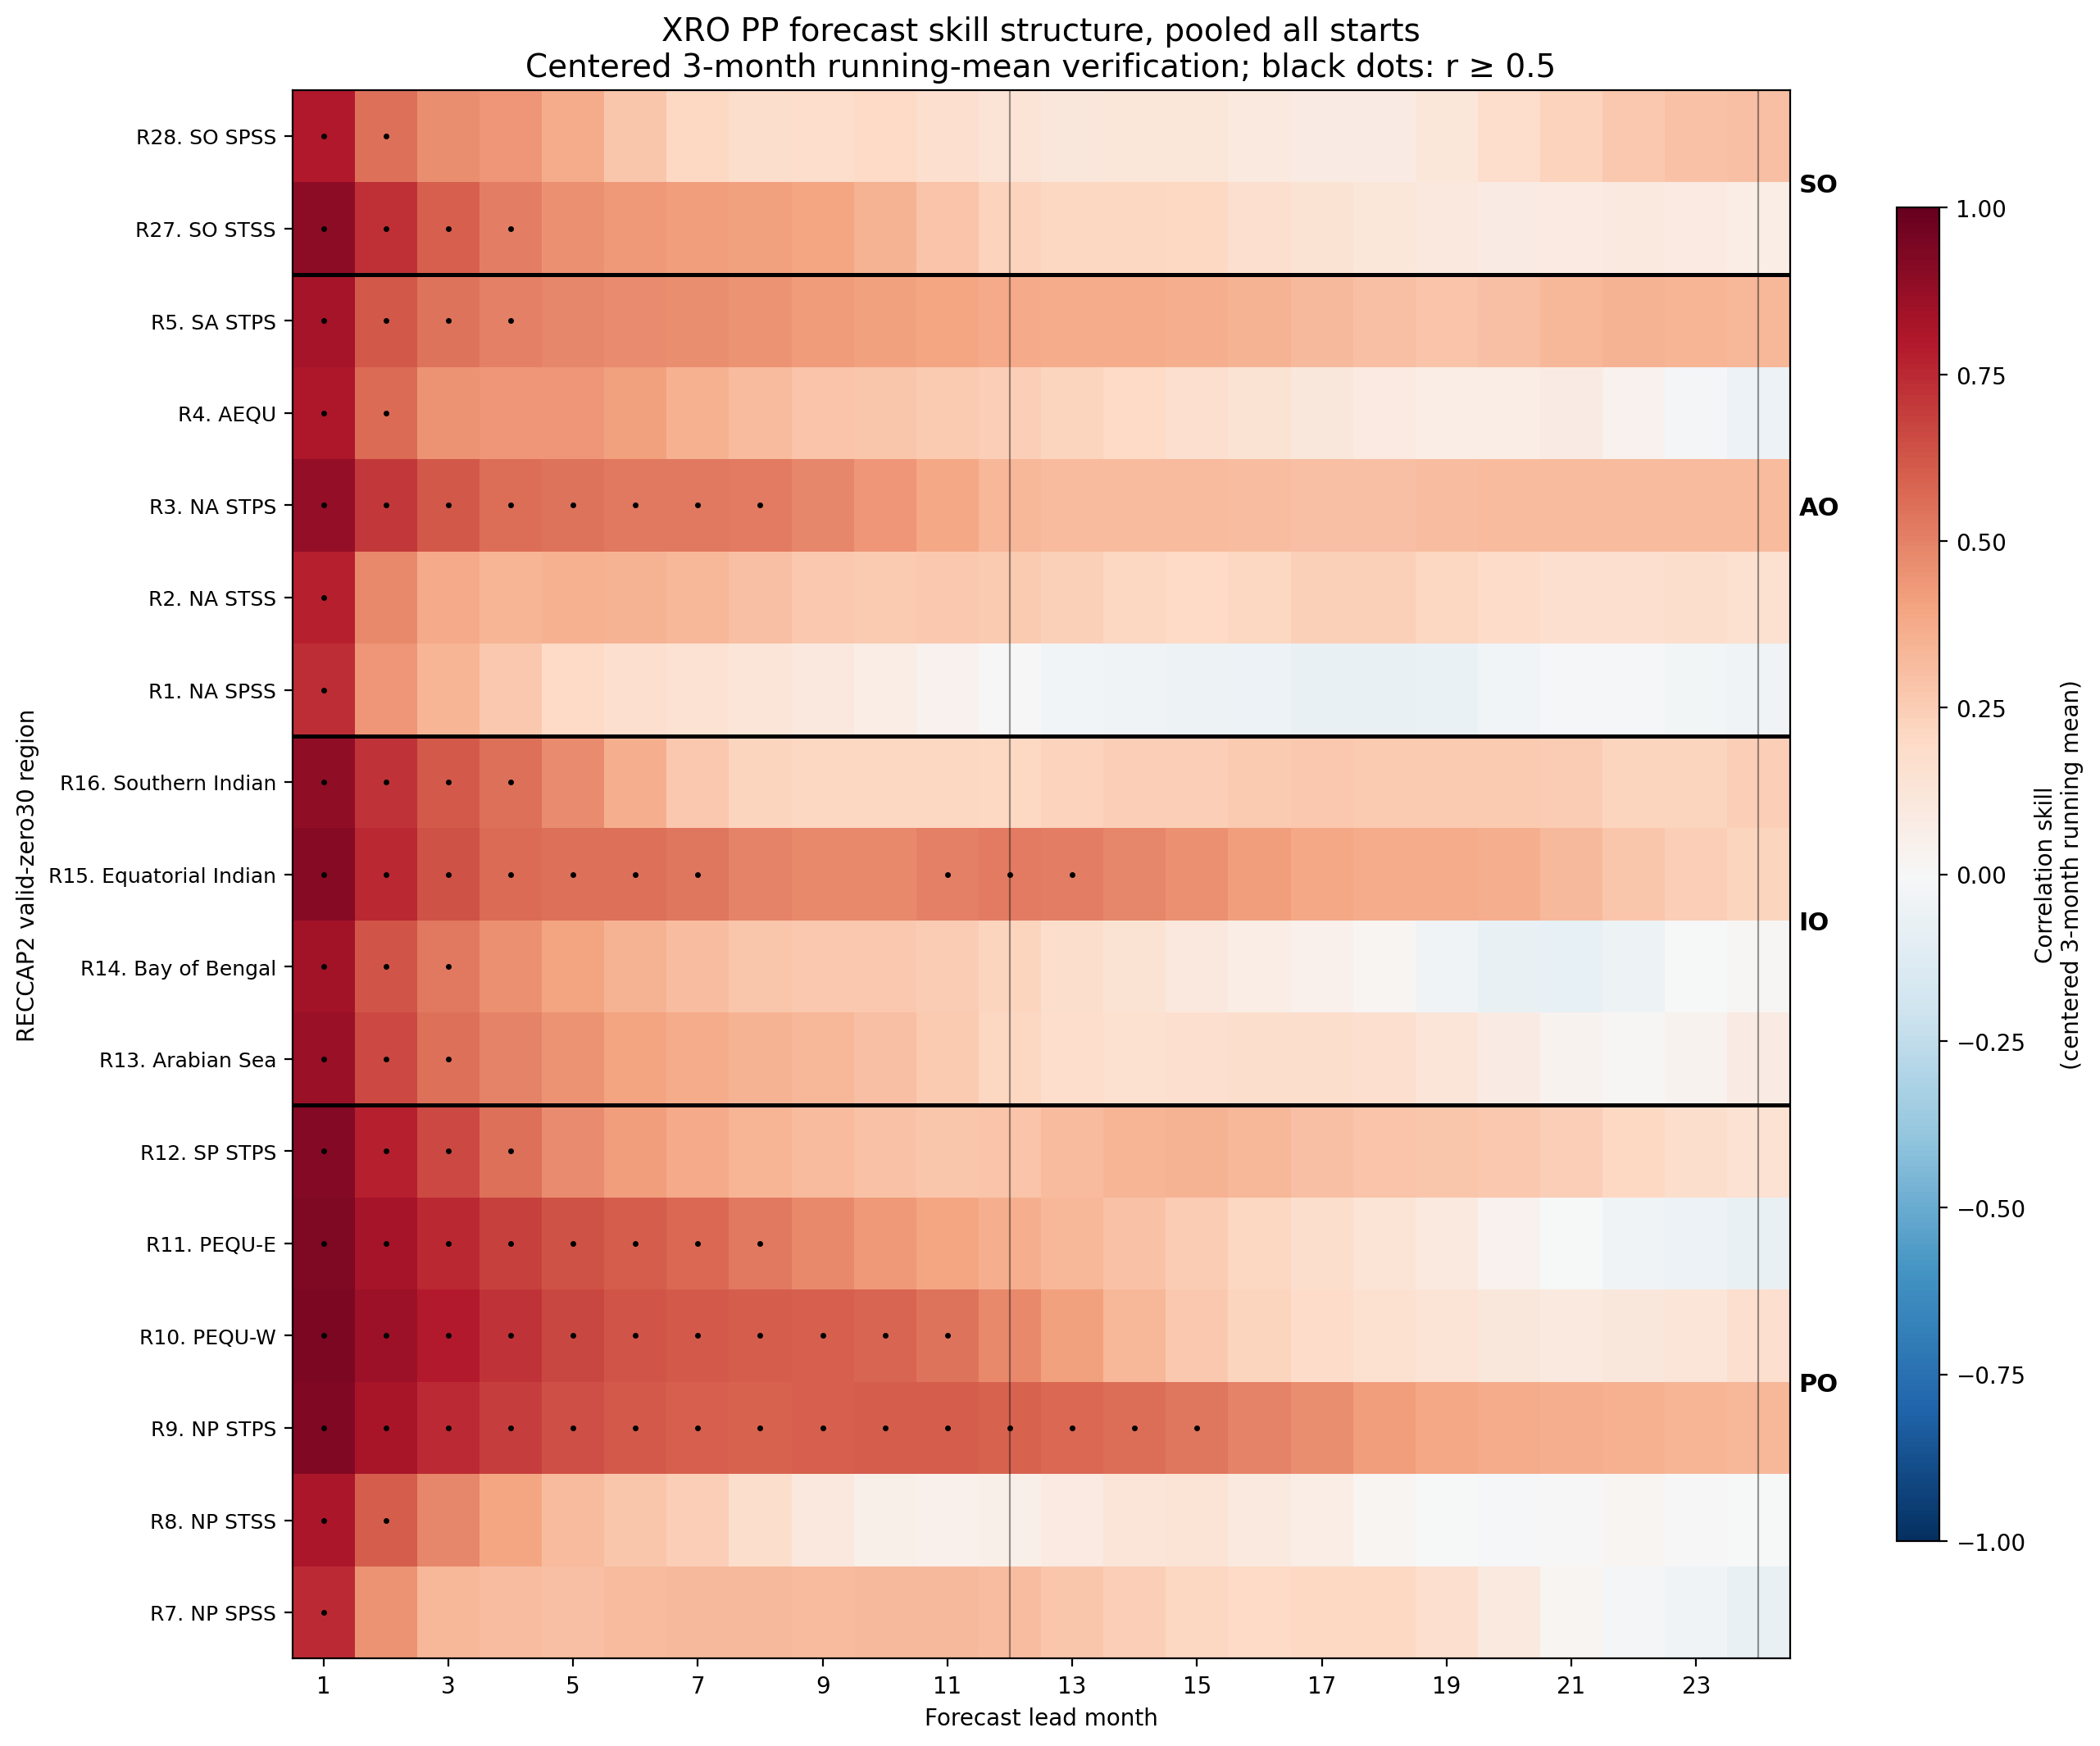

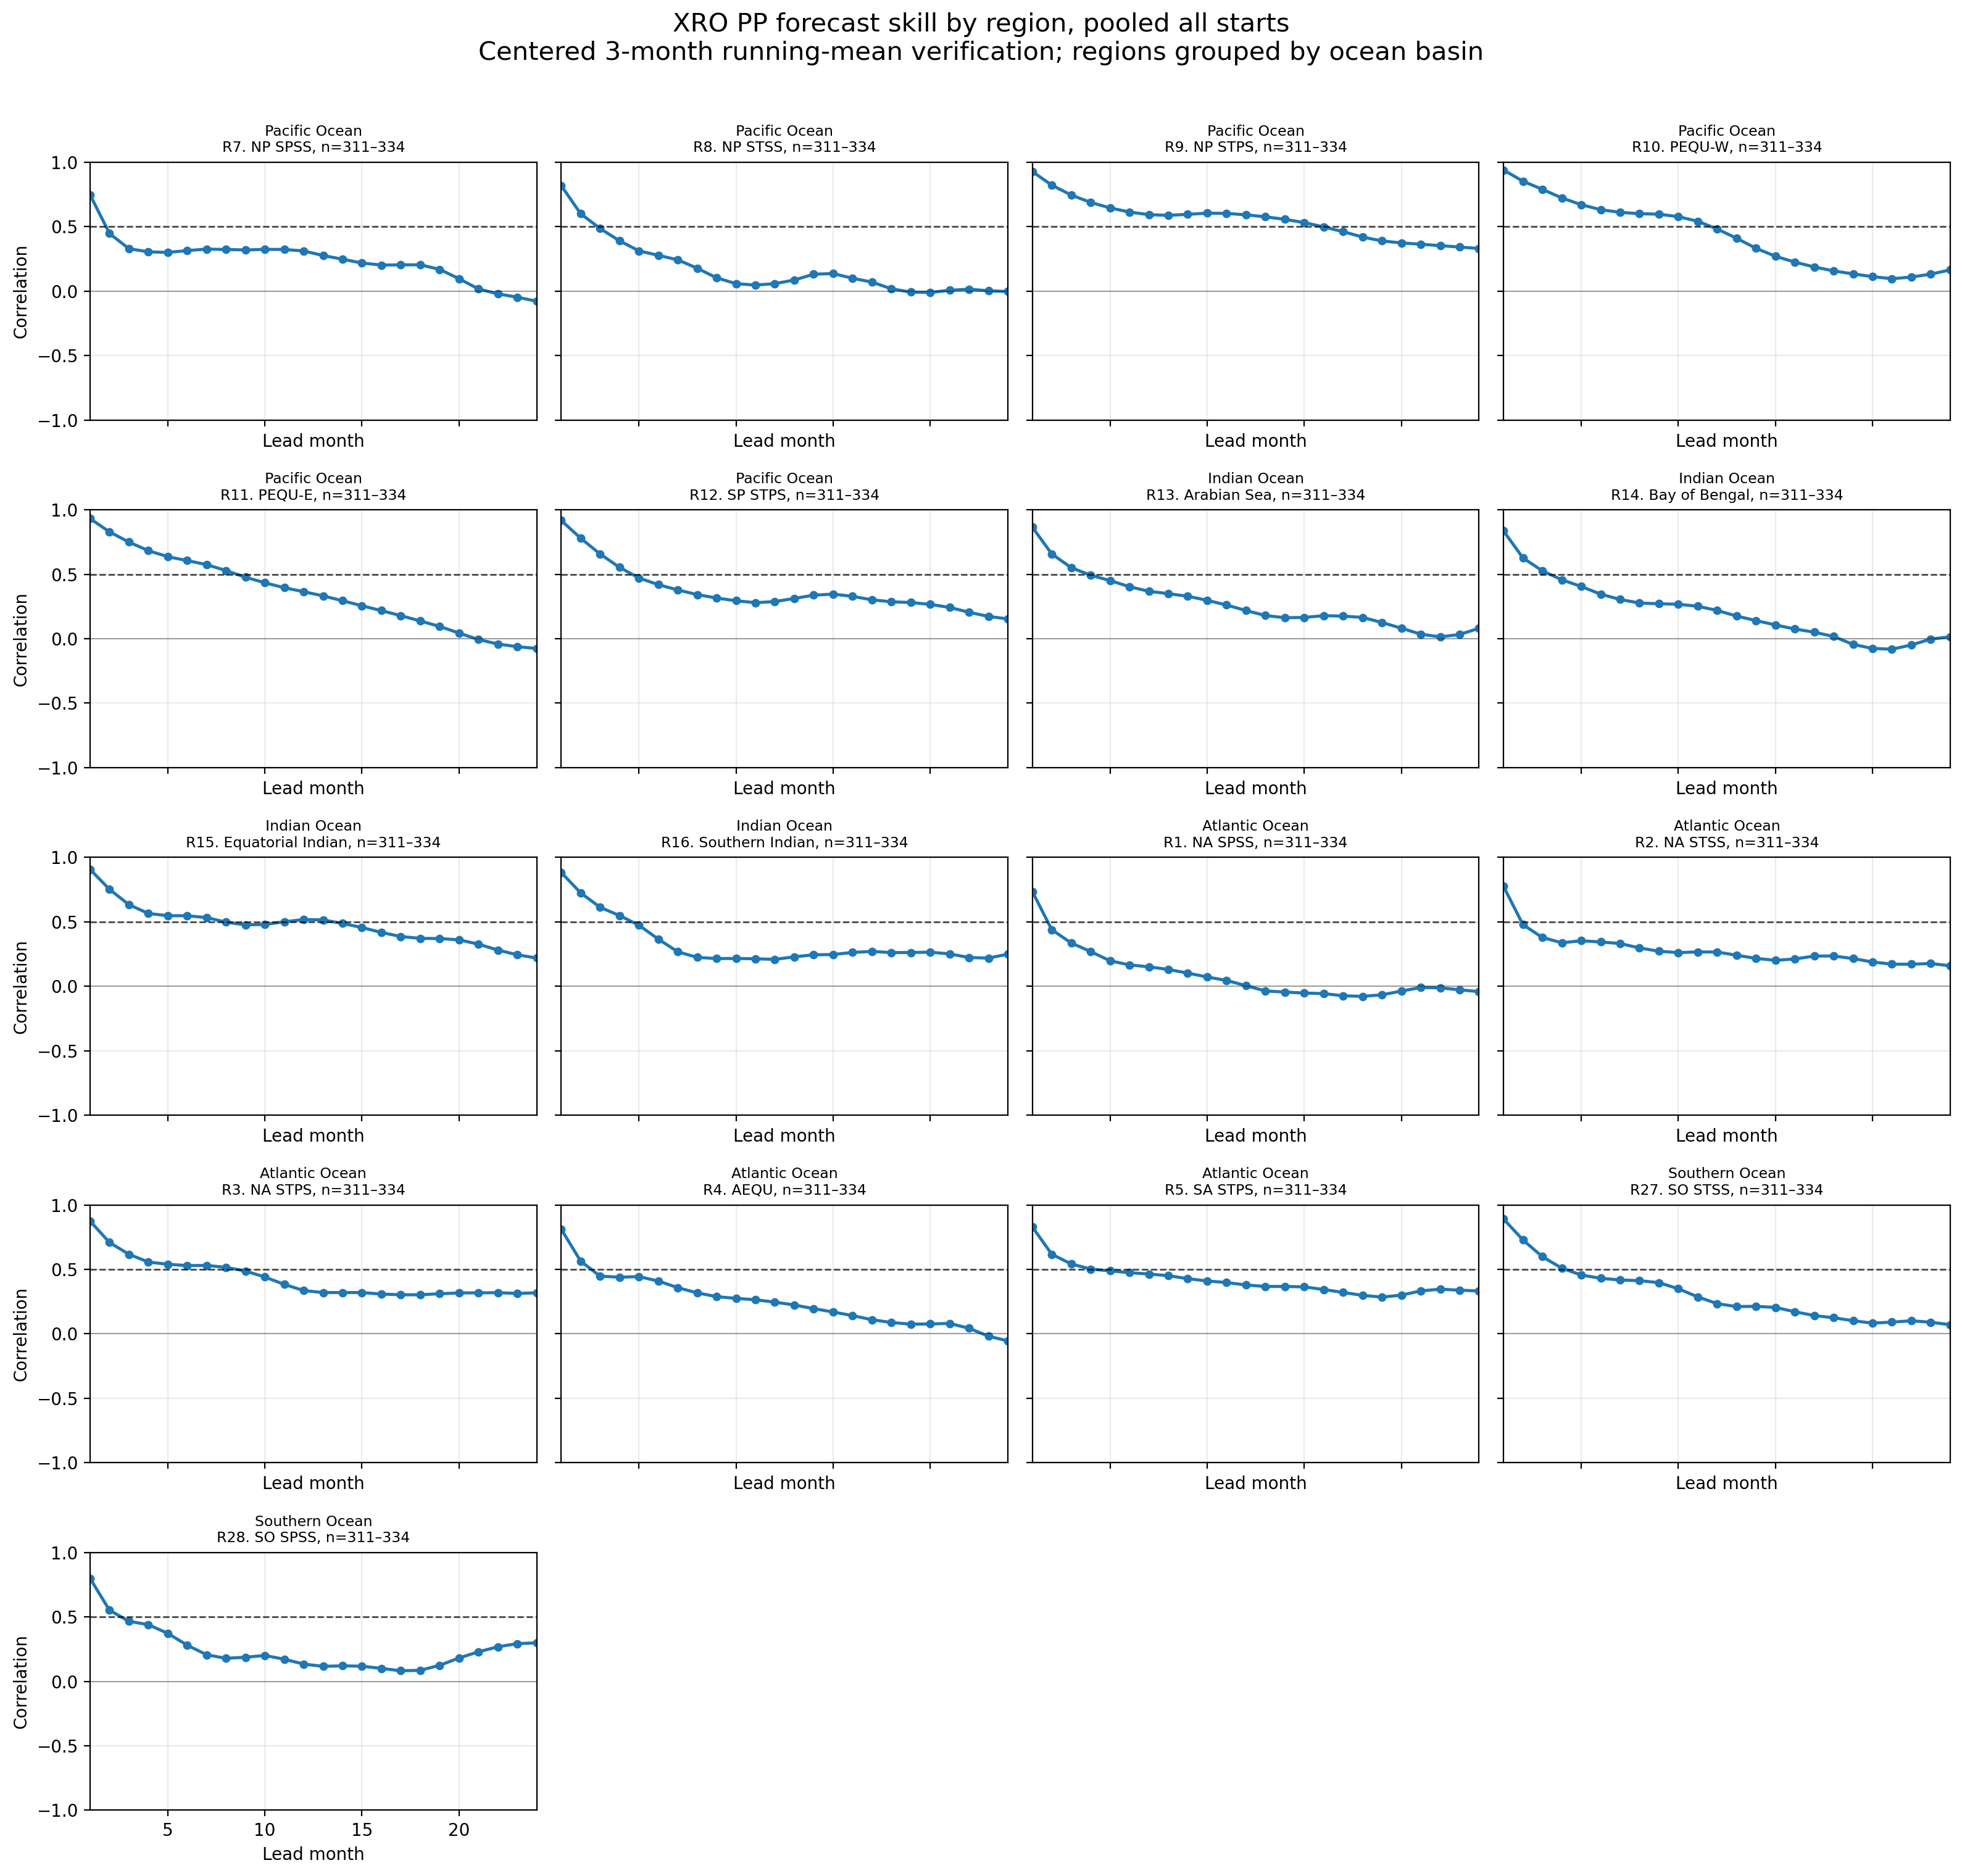

In [6]:
# ============================================================
# XRO PP skill structure using centered 3-month running mean
# pooled across all initialization months
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Settings
# ============================================================

SKILL_FILE = (
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/XRO/skill/"
    "XRO_PP_forecast_skill_24month_"
    "3month_running_mean_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

OUT_DIR = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/XRO/skill"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD = 0.5

# Regions excluded only from these figures
EXCLUDE_REGIONS = [6, 18, 19, 29]

FIG_HEATMAP = OUT_DIR / (
    "XRO_PP_skill_structure_3month_running_mean_"
    "pooled_all_starts_valid_zero30_allregions_heatmap.png"
)

FIG_LINES = OUT_DIR / (
    "XRO_PP_skill_structure_3month_running_mean_"
    "pooled_all_starts_valid_zero30_allregions_regional_lines.png"
)

BASIN_SHORT = {
    "Pacific Ocean": "PO",
    "Indian Ocean": "IO",
    "Atlantic Ocean": "AO",
    "Southern Ocean": "SO",
    "Arctic Ocean": "ArO",
}

BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]


# ============================================================
# Helper functions
# ============================================================

def decode_str(v):
    """
    Decode a netCDF string or byte-string scalar.
    """
    if isinstance(v, bytes):
        return v.decode("utf-8")

    arr = np.asarray(v)

    if arr.shape == ():
        item = arr.item()

        if isinstance(item, bytes):
            return item.decode("utf-8")

        return str(item)

    return str(v)


def get_region_label(ds, reg, short=True):
    """
    Return the region label used in plots.
    """
    reg = int(reg)

    if "region_name" in ds:
        try:
            name = decode_str(
                ds["region_name"].sel(region=reg).values
            )
        except Exception:
            name = f"region {reg}"
    else:
        name = f"region {reg}"

    if "basin" in ds:
        try:
            basin = decode_str(
                ds["basin"].sel(region=reg).values
            )
        except Exception:
            basin = ""
    else:
        basin = ""

    if "original_region_id" in ds:
        try:
            original_id = int(
                ds["original_region_id"]
                .sel(region=reg)
                .values
            )
        except Exception:
            original_id = -999
    else:
        original_id = -999

    if short:
        return f"R{reg}. {name}"

    if basin != "" and original_id > 0:
        return f"R{reg}. {basin}:{original_id} {name}"

    return f"R{reg}. {name}"


def get_basin_name(ds, reg):
    """
    Read the basin name and convert it to one of the five
    standard ocean names.
    """
    if "basin" not in ds:
        return "Unknown"

    try:
        raw = decode_str(
            ds["basin"].sel(region=int(reg)).values
        ).strip()
    except Exception:
        return "Unknown"

    name = raw.lower()

    if "pacific" in name:
        return "Pacific Ocean"

    if "indian" in name:
        return "Indian Ocean"

    if "atlantic" in name:
        return "Atlantic Ocean"

    if "southern" in name:
        return "Southern Ocean"

    if "arctic" in name:
        return "Arctic Ocean"

    return raw


# ============================================================
# Check file
# ============================================================

if not Path(SKILL_FILE).exists():
    raise FileNotFoundError(
        "The centered 3-month running-mean skill file "
        f"was not found:\n{SKILL_FILE}"
    )


# ============================================================
# Load pooled 3-month running-mean skill
# ============================================================

ds_skill = xr.open_dataset(SKILL_FILE)

required_variables = [
    "PP_correlation_skill",
    "n_pairs",
]

for var_name in required_variables:
    if var_name not in ds_skill:
        raise KeyError(
            f"{var_name} was not found in:\n{SKILL_FILE}"
        )

# Both variables are based on centered 3-month running-mean
# forecast and observed PP.
r_pool = ds_skill["PP_correlation_skill"]   # region, lead
n_pool = ds_skill["n_pairs"]                # region, lead

leads = r_pool["lead"].values.astype(np.int16)


# ============================================================
# Exclude selected regions
# ============================================================

keep_regions = [
    int(reg)
    for reg in r_pool["region"].values
    if int(reg) not in EXCLUDE_REGIONS
]

r_pool = r_pool.sel(region=keep_regions)
n_pool = n_pool.sel(region=keep_regions)


# ============================================================
# Identify basin for each retained region
# ============================================================

region_basin = {
    int(reg): get_basin_name(ds_skill, reg)
    for reg in keep_regions
}


# ============================================================
# Sort regions by basin
# ============================================================

basin_rank = {
    basin_name: i
    for i, basin_name in enumerate(BASIN_ORDER)
}

regions = np.array(
    sorted(
        keep_regions,
        key=lambda reg: (
            basin_rank.get(
                region_basin[reg],
                len(BASIN_ORDER),
            ),
            reg,
        ),
    ),
    dtype=np.int16,
)

r_pool = r_pool.sel(region=regions)
n_pool = n_pool.sel(region=regions)

n_region = len(regions)


# ============================================================
# Print summary
# ============================================================

print("Skill file:")
print(SKILL_FILE)

print("\nDataset:")
print(ds_skill)

print("\nSelected centered 3-month running-mean skill:")
print(r_pool)

print("\nRegions:")
for reg in regions:
    print(
        f"  {get_region_label(ds_skill, reg, short=False)}"
    )


# ============================================================
# Basin grouping information
# ============================================================

basin_groups = []

for basin_name in BASIN_ORDER:
    indices = [
        i
        for i, reg in enumerate(regions)
        if region_basin[int(reg)] == basin_name
    ]

    if len(indices) > 0:
        basin_groups.append(
            {
                "name": basin_name,
                "start": min(indices),
                "end": max(indices),
            }
        )

basin_centers = [
    0.5 * (group["start"] + group["end"] + 1)
    for group in basin_groups
]

basin_labels = [
    BASIN_SHORT.get(
        group["name"],
        group["name"],
    )
    for group in basin_groups
]


# ============================================================
# 1. Heatmap: region x lead
# ============================================================

fig, ax = plt.subplots(
    figsize=(14.5, 0.48 * n_region + 3.8)
)

y_edges = np.arange(n_region + 1)

x_edges = np.arange(
    leads[0] - 0.5,
    leads[-1] + 1.5,
    1.0,
)

im = ax.pcolormesh(
    x_edges,
    y_edges,
    r_pool.values,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    shading="auto",
)

rr = r_pool.values


# ------------------------------------------------------------
# Mark cells where r >= threshold
# ------------------------------------------------------------

for ireg, reg in enumerate(regions):
    y = ireg + 0.5

    for ilead, lead in enumerate(leads):
        value = rr[ireg, ilead]

        if (
            np.isfinite(value)
            and value >= THRESHOLD
        ):
            ax.plot(
                lead,
                y,
                "k.",
                markersize=3,
            )


# ------------------------------------------------------------
# Thick lines between ocean basins
# ------------------------------------------------------------

for group in basin_groups[:-1]:
    boundary = group["end"] + 1

    ax.axhline(
        boundary,
        color="k",
        lw=1.8,
    )


# ------------------------------------------------------------
# Basin labels on right side
# ------------------------------------------------------------

ax_basin = ax.twinx()

ax_basin.set_ylim(0, n_region)
ax_basin.set_yticks(basin_centers)
ax_basin.set_yticklabels(
    basin_labels,
    fontsize=11,
    fontweight="bold",
)

ax_basin.tick_params(
    axis="y",
    which="both",
    length=0,
    pad=4,
)

ax_basin.set_ylabel("")

for spine in ax_basin.spines.values():
    spine.set_visible(False)


# ------------------------------------------------------------
# Reference lead lines
# ------------------------------------------------------------

if leads[-1] >= 12:
    ax.axvline(
        12,
        color="k",
        lw=0.8,
        alpha=0.4,
    )

if leads[-1] >= 24:
    ax.axvline(
        24,
        color="k",
        lw=0.8,
        alpha=0.4,
    )


# ------------------------------------------------------------
# Axes and labels
# ------------------------------------------------------------

ax.set_xlim(
    leads[0] - 0.5,
    leads[-1] + 0.5,
)

ax.set_ylim(0, n_region)

ax.set_xlabel("Forecast lead month")

ax.set_ylabel(
    "RECCAP2 valid-zero30 region"
)

ax.set_title(
    "XRO PP forecast skill structure, pooled all starts\n"
    "Centered 3-month running-mean verification; "
    f"black dots: r ≥ {THRESHOLD}",
    fontsize=14,
)

ax.set_xticks(
    np.arange(
        leads[0],
        leads[-1] + 1,
        2,
    )
)

ax.set_yticks(
    np.arange(n_region) + 0.5
)

ax.set_yticklabels(
    [
        get_region_label(
            ds_skill,
            reg,
            short=True,
        )
        for reg in regions
    ],
    fontsize=9,
)


# ------------------------------------------------------------
# Figure and colorbar position
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.20,
    right=0.83,
    top=0.90,
    bottom=0.10,
)

cax = fig.add_axes(
    [0.875, 0.16, 0.018, 0.68]
)

cbar = fig.colorbar(
    im,
    cax=cax,
)

cbar.set_label(
    "Correlation skill\n"
    "(centered 3-month running mean)"
)

plt.show()

# fig.savefig(
#     FIG_HEATMAP,
#     dpi=200,
#     bbox_inches="tight",
# )
# print(f"Saved: {FIG_HEATMAP}")


# ============================================================
# 2. Regional line panels
# ============================================================

ncol = 4
nrow = int(
    np.ceil(n_region / ncol)
)

fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(16, 3.0 * nrow),
    sharex=True,
    sharey=True,
)

axes = np.asarray(axes).ravel()


for ax, reg in zip(axes, regions):
    r = r_pool.sel(region=reg)
    n = n_pool.sel(region=reg)

    basin = region_basin[int(reg)]

    label = get_region_label(
        ds_skill,
        reg,
        short=True,
    )

    ax.plot(
        leads,
        r.values,
        marker="o",
        lw=1.8,
        ms=4,
        label="XRO pooled, 3-month mean",
    )

    ax.axhline(
        THRESHOLD,
        color="k",
        lw=1.0,
        ls="--",
        alpha=0.7,
    )

    ax.axhline(
        0,
        color="k",
        lw=0.6,
        alpha=0.4,
    )

    finite_n = n.values[
        np.isfinite(n.values)
    ]

    if finite_n.size > 0:
        n_text = (
            f"n={int(np.nanmin(finite_n))}"
            f"–{int(np.nanmax(finite_n))}"
        )
    else:
        n_text = "n=NA"

    ax.set_title(
        f"{basin}\n"
        f"{label}, {n_text}",
        fontsize=8.5,
    )

    ax.set_xlim(
        leads[0],
        leads[-1],
    )

    ax.set_ylim(-1, 1)

    ax.grid(
        alpha=0.25
    )


# Hide unused axes
for ax in axes[n_region:]:
    ax.axis("off")


# X-axis labels
for ax in axes:
    if ax.get_visible():
        ax.set_xlabel(
            "Lead month"
        )


# Y-axis labels on first column
for i, ax in enumerate(axes[:n_region]):
    if i % ncol == 0:
        ax.set_ylabel(
            "Correlation"
        )


fig.suptitle(
    "XRO PP forecast skill by region, pooled all starts\n"
    "Centered 3-month running-mean verification; "
    "regions grouped by ocean basin",
    fontsize=15,
    y=1.01,
)

plt.tight_layout()

plt.show()

# fig.savefig(
#     FIG_LINES,
#     dpi=200,
#     bbox_inches="tight",
# )
# print(f"Saved: {FIG_LINES}")


# ============================================================
# Close dataset
# ============================================================

ds_skill.close()